# Stop/Save Behavioral EDA — Complete Analysis

This notebook consolidates the population-level EDA and focused behavioral profiling. Its purpose is to characterize Saved and Stopped users; the completed treatment/CNRC evaluation remains outside this repository.

Repeated callers are handled deliberately: they are compared with called-once users as a separate business diagnostic, then excluded from the behavioral reference, Saved-versus-Stopped segment discovery, ranking, and Treatment drill-down. Treatment is used only after the strongest pooled-treatment behavioral segments have been selected.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.eda_helpers import (
    ID_COL,
    OUTCOME_COL,
    OUTCOMES,
    build_behavior_profiles,
    build_distribution_summary,
    build_outcome_contrasts,
    build_segment_summary,
    build_selected_segment_detail_table,
    build_treatment_contrasts,
    fit_behavior_reference,
    plot_metric_boxplot_views,
    plot_profile_or_contrast_heatmap,
    plot_selected_segment_clipped_boxplot_grid,
    plot_top_behavior_contrasts,
)

In [3]:
PROJECT_ID = "gannett-datascience"
TABLE_ID = "gannett-datascience.test_results_zone.ss_test_result_v3-2"

NUMERIC_FIELDS = ["frequency", "breadth", "tenure", "tt_cost"]
SUMMARY_SEGMENT_FIELDS = [
    "src_risk_tier",
    "cohort",
    "Treatment",
    "contact_channel_group",
    OUTCOME_COL,
    "contact_timing",
]
BASE_SEGMENT_FIELDS = [
    "contact_channel_group",
    "contact_timing",
    "cohort",
    "src_risk_tier",
]
PROFILE_FIELDS = [OUTCOME_COL, *BASE_SEGMENT_FIELDS]
MIN_PROFILE_USERS = 20
MIN_TREATMENT_USERS = 5
TOP_CONTRASTS = 8
BOOTSTRAP_ITERATIONS = 2_000  # Set to 0 to skip confidence intervals.
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

OUTPUT_ROOT = PROJECT_ROOT / "src" / "notebooks"
CHART_DIR = OUTPUT_ROOT / "charts" / "eda_complete"
TABLE_DIR = OUTPUT_ROOT / "tables" / "eda_complete"
OVERVIEW_CHART_DIR = CHART_DIR / "overview"
DIAGNOSTIC_CHART_DIR = CHART_DIR / "diagnostics"
PROFILE_CHART_DIR = CHART_DIR / "profiles"
CONTRAST_CHART_DIR = CHART_DIR / "contrasts"
for folder in [
    OVERVIEW_CHART_DIR,
    DIAGNOSTIC_CHART_DIR,
    PROFILE_CHART_DIR,
    CONTRAST_CHART_DIR,
    TABLE_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

## 1. Load once and define the analysis populations

The maturity cutoff is already agreed business logic. The source also handles billing adjustments and excludes conflicting permanent-stop versus event classifications. One billing account is one subscriber.

In [4]:
QUERY_FIELDS = [
    ID_COL,
    "id_subscrip",
    "email_date",
    "status",
    "Treatment",
    "contact_channel",
    "contact_timing",
    "cohort",
    "repeatedly_called",
    "src_risk_tier",
    *NUMERIC_FIELDS,
]
query = f"""
SELECT
  {', '.join(QUERY_FIELDS)}
FROM `{TABLE_ID}`
WHERE email_date < '2026-05-01'
"""

client = bigquery.Client(project=PROJECT_ID)
df = client.query(query).to_dataframe()
df[NUMERIC_FIELDS] = df[NUMERIC_FIELDS].astype("float64")
df["contact_channel_group"] = df["contact_channel"].replace(
    {
        "Online first": "Contacted both ways",
        "Called-In first": "Contacted both ways",
    }
)
df["repeated_call_group"] = np.where(
    df["repeatedly_called"].fillna(0).astype(int).eq(1),
    "Repeatedly Called",
    "Called Once",
)
df[OUTCOME_COL] = df["status"].map(
    {"saved": "Saved", "stoped": "Stopped"}
)
risk_tier = df["src_risk_tier"].astype("string")
df["src_risk_tier"] = risk_tier.where(
    risk_tier.isna() | risk_tier.str.endswith(" risk"),
    risk_tier + " risk",
)

df_no_action = df[df["status"].eq("No Action yet")].copy()
df_contacted = df[df["status"].isin(["saved", "stoped"])].copy()
df_repeated = df_contacted[
    df_contacted["repeated_call_group"].eq("Repeatedly Called")
].copy()
df_analysis = df_contacted[
    df_contacted["repeated_call_group"].eq("Called Once")
].copy()
df_saved = df_analysis[df_analysis[OUTCOME_COL].eq("Saved")].copy()
df_stopped = df_analysis[df_analysis[OUTCOME_COL].eq("Stopped")].copy()

if df_analysis.empty:
    raise ValueError("The called-once contacted population is empty.")
if df[ID_COL].isna().any() or df[ID_COL].duplicated().any():
    raise ValueError("The source must contain one non-missing row per billing account.")
empty_metrics = [
    metric for metric in NUMERIC_FIELDS
    if df_analysis[metric].notna().sum() == 0
]
if empty_metrics:
    raise ValueError(f"Primary analysis metrics contain no values: {empty_metrics}")

/Users/YKang1/PycharmProjects/stop_save_pChurn/.venv/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/YKang1/PycharmProjects/stop_save_pChurn/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [5]:
population_counts = pd.DataFrame(
    {
        "population": [
            "All mature notified users",
            "No Action yet",
            "Classified contacted users",
            "Repeated callers — diagnostic only",
            "Called once — primary analysis",
            "Called once and Saved",
            "Called once and Stopped",
        ],
        "accounts": [
            df[ID_COL].nunique(),
            df_no_action[ID_COL].nunique(),
            df_contacted[ID_COL].nunique(),
            df_repeated[ID_COL].nunique(),
            df_analysis[ID_COL].nunique(),
            df_saved[ID_COL].nunique(),
            df_stopped[ID_COL].nunique(),
        ],
    }
)
population_counts["share_of_all_pct"] = (
    population_counts["accounts"] / df[ID_COL].nunique() * 100
)
population_counts.to_csv(TABLE_DIR / "population_counts.csv", index=False)
population_counts

,population,accounts,share_of_all_pct
0,All mature notified users,9398,100.00
1,No Action yet,7867,83.71
2,Classified contacted users,1531,16.29
3,Repeated callers — diagnostic only,13,0.14
4,Called once — primary analysis,1518,16.15
5,Called once and Saved,576,6.13
6,Called once and Stopped,942,10.02


## 2. Population context and data quality

The combined population-metric summary retains magnitude, missingness, percentiles, and IQR outliers without recalculating quartiles in a separate table. The later behavioral workflow uses only called-once contacted users.

In [6]:
context_populations = {
    "No Action yet": df_no_action,
    "Called once — primary": df_analysis,
    "Called once and Saved": df_saved,
    "Called once and Stopped": df_stopped,
}
distribution_summary = pd.concat(
    [
        build_distribution_summary(frame, NUMERIC_FIELDS).assign(population=name)
        for name, frame in context_populations.items()
    ],
    ignore_index=True,
)
distribution_summary.to_csv(TABLE_DIR / "distribution_summary.csv", index=False)
display(distribution_summary.head(5))

,field,row_count,non_null_count,null_count,null_pct,zero_count,negative_count,min,max,mean,median,std,p01,p05,p10,p25,p50,p75,p90,p95,p99,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,population
0,frequency,7867,7861,6,0.08,1632,0,0.00,91.00,38.46,29.00,35.37,0.00,0.00,0.00,2.00,29.00,77.00,90.00,91.00,91.00,75.00,-110.50,189.50,0,0.00,No Action yet
1,breadth,7867,7861,6,0.08,2466,0,0.00,21.00,4.18,3.00,4.24,0.00,0.00,0.00,0.00,3.00,7.00,10.00,12.00,16.00,7.00,-10.50,17.50,22,0.28,No Action yet
2,tenure,7867,7861,6,0.08,0,0,208.00,"27,867.00","1,382.95","1,354.00",886.36,324.00,337.00,504.00,997.00,"1,354.00","1,635.00","2,069.00","2,460.00","3,405.80",638.00,40.00,"2,592.00",281,3.57,No Action yet
3,tt_cost,7867,7861,6,0.08,32,0,0.00,"9,279.71",571.25,502.83,439.16,107.89,112.89,166.27,374.25,502.83,704.96,949.38,"1,279.15","1,764.45",330.71,-121.82,"1,201.03",458,5.83,No Action yet
4,frequency,1518,1516,2,0.13,183,0,0.00,91.00,45.69,45.00,34.52,0.00,0.00,0.00,9.00,45.00,82.00,90.00,91.00,91.00,73.00,-100.50,191.50,0,0.00,Called once — primary


In [7]:
segment_summaries = []
for segment in SUMMARY_SEGMENT_FIELDS:
    summary = build_segment_summary(df_analysis, segment, NUMERIC_FIELDS)
    summary = summary.rename(columns={segment: "segment_value"})
    summary.insert(0, "segment_field", segment)
    segment_summaries.append(summary)
segment_summaries = pd.concat(segment_summaries, ignore_index=True)
segment_summaries.to_csv(TABLE_DIR / "primary_segment_summaries.csv", index=False)
segment_summaries.head(10)

,segment_field,segment_value,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,p90_tenure,avg_tt_cost,median_tt_cost,p90_tt_cost
0,src_risk_tier,1. Low risk,555,69.26,82.00,91.00,6.76,7.00,12.00,"1,627.11","1,544.00","2,397.60",509.41,433.23,847.33
1,src_risk_tier,<NA>,522,39.52,32.00,88.00,4.60,4.00,10.10,"1,386.56","1,384.50","2,157.50",463.07,442.22,779.43
2,src_risk_tier,2. Med-Low risk,196,38.00,38.00,70.50,4.93,4.00,10.00,"1,801.15","1,726.50","2,517.00",673.16,624.21,"1,114.85"
3,src_risk_tier,3. Medium risk,170,12.21,6.00,36.20,2.11,1.00,7.00,"1,300.71","1,388.00","1,663.00",500.34,484.44,800.63
4,src_risk_tier,4. Med-High risk,74,10.16,4.50,27.10,2.23,1.00,6.00,"1,027.09",966.00,"1,481.70",336.22,303.86,500.42
5,src_risk_tier,5. High risk,1,1.00,1.00,1.00,1.00,1.00,1.00,"1,241.00","1,241.00","1,241.00",413.25,413.25,413.25
6,cohort,Three-Offer Cohort,996,48.91,52.00,91.00,5.26,5.00,11.00,"1,560.68","1,465.00","2,364.00",527.12,483.02,846.91
7,cohort,Two-Offer Cohort,522,39.52,32.00,88.00,4.60,4.00,10.10,"1,386.56","1,384.50","2,157.50",463.07,442.22,779.43
8,Treatment,Midpoint,610,45.44,45.00,90.00,5.11,5.00,11.00,"1,457.27","1,421.50","2,239.00",494.55,470.78,798.20
9,Treatment,Control,590,43.58,41.50,90.00,4.70,4.00,11.00,"1,497.12","1,451.50","2,301.10",490.56,452.21,805.58


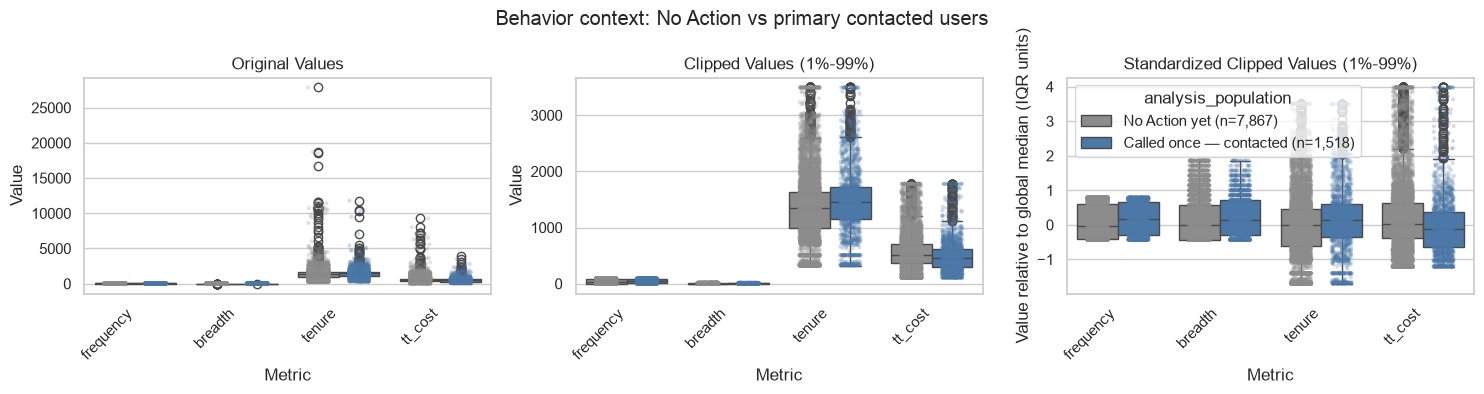

In [8]:
context_comparison = pd.concat(
    [
        df_no_action.assign(analysis_population="No Action yet"),
        df_analysis.assign(analysis_population="Called once — contacted"),
    ],
    ignore_index=True,
)
_ = plot_metric_boxplot_views(
    context_comparison,
    metrics=NUMERIC_FIELDS,
    group_col="analysis_population",
    group_order=["No Action yet", "Called once — contacted"],
    chart_title="Behavior context: No Action vs primary contacted users",
    chart_folder=OVERVIEW_CHART_DIR,
    file_name="no_action_vs_primary_contacted.png",
    show=True,
)

## 3. Repeated-call diagnostic

The business hypothesis is that repeatedly called users differ by nature. This comparison describes that difference, but repeat calling is post-contact behavior and its group may be small. It is therefore not mixed into the baseline or any downstream Saved-versus-Stopped analysis.

,field,row_count,non_null_count,null_count,null_pct,zero_count,negative_count,min,max,mean,median,std,p01,p05,p10,p25,p50,p75,p90,p95,p99,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,repeated_call_group
0,frequency,1518,1516,2,0.13,183,0,0.00,91.00,45.69,45.00,34.52,0.00,0.00,0.00,9.00,45.00,82.00,90.00,91.00,91.00,73.00,-100.50,191.50,0,0.00,Called Once
1,breadth,1518,1516,2,0.13,292,0,0.00,20.00,5.03,4.00,4.19,0.00,0.00,0.00,1.00,4.00,8.00,11.00,13.00,15.85,7.00,-9.50,18.50,1,0.07,Called Once
2,tenure,1518,1516,2,0.13,0,0,323.00,"11,789.00","1,500.95","1,450.00",820.13,325.15,358.75,689.50,"1,144.00","1,450.00","1,728.25","2,328.00","2,637.50","3,811.20",584.25,267.62,"2,604.62",85,5.61,Called Once
3,tt_cost,1518,1516,2,0.13,0,0,25.91,"3,925.74",505.15,463.20,337.21,108.23,119.76,169.16,289.96,463.20,621.90,826.59,"1,002.87","1,797.13",331.94,-207.95,"1,119.82",60,3.96,Called Once
4,frequency,13,12,1,7.69,0,0,27.00,91.00,73.00,89.00,22.97,28.98,36.90,45.70,53.50,89.00,90.25,91.00,91.00,91.00,36.75,-1.62,145.38,0,0.00,Repeatedly Called
5,breadth,13,12,1,7.69,0,0,2.00,14.00,6.00,5.00,3.49,2.11,2.55,3.00,3.75,5.00,7.50,9.90,11.80,13.56,3.75,-1.88,13.12,1,8.33,Repeatedly Called
6,tenure,13,12,1,7.69,0,0,357.00,"3,642.00","1,619.92","1,432.00",879.57,410.46,624.30,867.70,"1,248.25","1,432.00","1,725.50","2,777.30","3,227.30","3,559.06",477.25,532.38,"2,441.38",3,25.00,Repeatedly Called
7,tt_cost,13,12,1,7.69,0,0,50.99,"1,109.44",407.48,418.10,286.25,62.38,107.96,157.67,208.67,418.10,450.26,701.71,898.72,"1,067.30",241.59,-153.71,812.65,1,8.33,Repeatedly Called


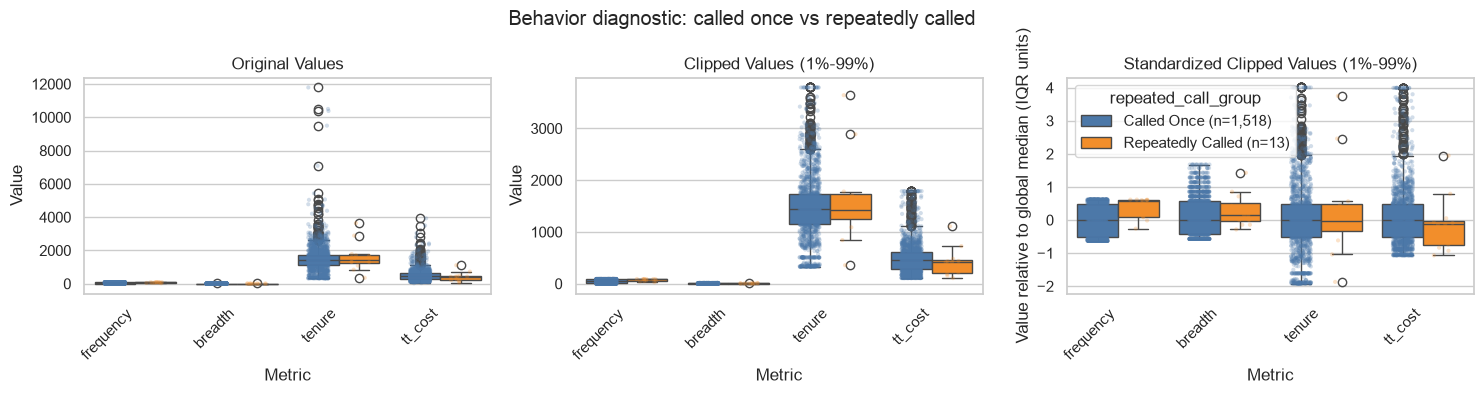

In [9]:
repeated_call_summary = pd.concat(
    [
        build_distribution_summary(group, NUMERIC_FIELDS).assign(
            repeated_call_group=group_name
        )
        for group_name, group in df_contacted.groupby(
            "repeated_call_group", observed=True
        )
    ],
    ignore_index=True,
)
repeated_call_summary.to_csv(
    TABLE_DIR / "repeated_call_behavior_summary.csv", index=False
)
display(repeated_call_summary)
_ = plot_metric_boxplot_views(
    df_contacted,
    metrics=NUMERIC_FIELDS,
    group_col="repeated_call_group",
    group_order=["Called Once", "Repeatedly Called"],
    chart_title="Behavior diagnostic: called once vs repeatedly called",
    chart_folder=DIAGNOSTIC_CHART_DIR,
    file_name="called_once_vs_repeatedly_called.png",
    show=True,
)

## 4. Primary called-once Saved-versus-Stopped baseline

All remaining calculations use `df_analysis`. The common reference is fitted once on this entire called-once contacted population: clip each metric at its population 1st and 99th percentiles, subtract its population median, then divide by its population IQR.

In [10]:
behavior_reference = fit_behavior_reference(df_analysis, NUMERIC_FIELDS)
reference_table = pd.DataFrame(
    {
        "p01": behavior_reference["lower_bounds"],
        "median": behavior_reference["centers"],
        "iqr": behavior_reference["spreads"],
        "p99": behavior_reference["upper_bounds"],
    }
).rename_axis("metric").reset_index()
reference_table.to_csv(TABLE_DIR / "primary_behavior_reference.csv", index=False)
reference_table

,metric,p01,median,iqr,p99
0,frequency,0.00,45.00,73.00,91.00
1,breadth,0.00,4.00,7.00,15.85
2,tenure,325.15,"1,450.00",584.25,"3,811.20"
3,tt_cost,108.23,463.20,331.94,"1,797.13"


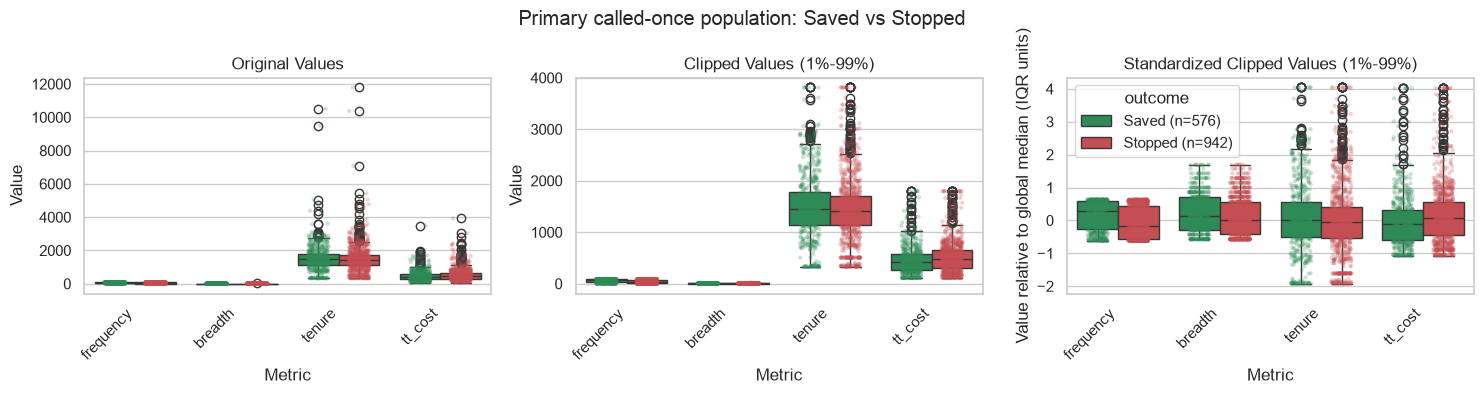

In [11]:
_ = plot_metric_boxplot_views(
    df_analysis,
    metrics=NUMERIC_FIELDS,
    group_col=OUTCOME_COL,
    group_order=list(OUTCOMES),
    chart_title="Primary called-once population: Saved vs Stopped",
    chart_folder=OVERVIEW_CHART_DIR,
    file_name="primary_saved_vs_stopped.png",
    show=True,
)

## 5. Absolute behavior profiles

Profiles answer: which adequately supported Saved or Stopped slices sit above or below the same called-once population reference? Treatment and repeated-call status are not profile dimensions.

,outcome,contact_channel_group,contact_timing,cohort,src_risk_tier,segment_label,users,median__frequency,median__breadth,median__tenure,median__tt_cost,score__frequency,score__breadth,score__tenure,score__tt_cost,profile_magnitude,dominant_metric
0,Stopped,Online Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Stopped · Online Cancel Flow · Contact On/Afte...,55,2.00,0.00,"1,180.00",372.29,-0.59,-0.57,-0.46,-0.27,0.98,frequency
1,Stopped,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Stopped · Called-In Cancel Flow · Contact On/A...,28,22.00,4.00,"1,832.00",662.34,-0.32,0.00,0.65,0.60,0.94,tenure
2,Stopped,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,2. Med-Low risk,Stopped · Called-In Cancel Flow · Contact Befo...,37,34.00,4.00,"1,815.00",656.01,-0.15,0.00,0.62,0.58,0.87,tenure
3,Stopped,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,3. Medium risk,Stopped · Called-In Cancel Flow · Contact On/A...,27,1.00,0.00,"1,363.00",502.16,-0.60,-0.57,-0.15,0.12,0.85,frequency
4,Stopped,Online Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,1. Low risk,Stopped · Online Cancel Flow · Contact On/Afte...,34,82.50,7.00,"1,709.50",536.30,0.51,0.43,0.44,0.22,0.83,frequency
5,Stopped,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,3. Medium risk,Stopped · Called-In Cancel Flow · Contact Befo...,37,2.00,0.00,"1,391.00",494.17,-0.59,-0.57,-0.10,0.09,0.83,frequency
6,Saved,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,1. Low risk,Saved · Called-In Cancel Flow · Contact On/Aft...,78,87.50,7.00,"1,526.00",447.24,0.58,0.43,0.13,-0.05,0.74,frequency
7,Stopped,Online Cancel Flow,Contact Before Pricing,Three-Offer Cohort,2. Med-Low risk,Stopped · Online Cancel Flow · Contact Before ...,49,37.00,5.00,"1,697.00",635.70,-0.11,0.14,0.42,0.52,0.69,tt_cost
8,Stopped,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,1. Low risk,Stopped · Called-In Cancel Flow · Contact Befo...,117,82.00,7.00,"1,544.00",474.19,0.51,0.43,0.16,0.03,0.68,frequency
9,Saved,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,1. Low risk,Saved · Called-In Cancel Flow · Contact Before...,124,83.50,6.00,"1,567.00",382.28,0.53,0.29,0.20,-0.24,0.68,frequency


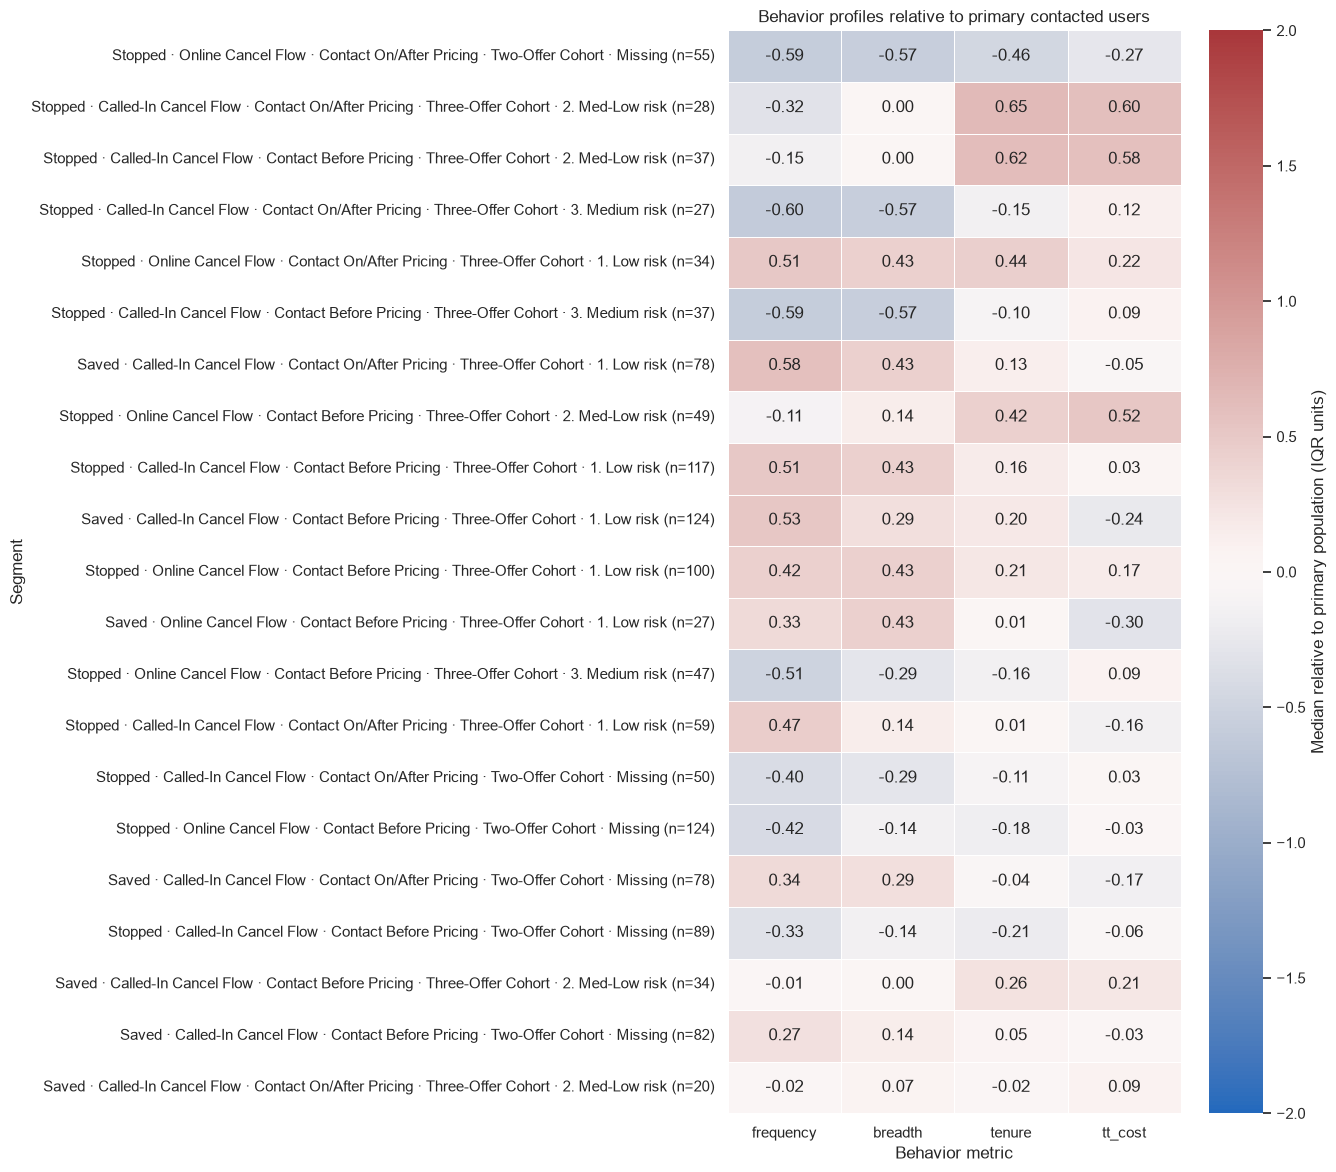

In [12]:
behavior_profiles = build_behavior_profiles(
    df_analysis,
    metrics=NUMERIC_FIELDS,
    segment_fields=PROFILE_FIELDS,
    reference=behavior_reference,
    min_n=MIN_PROFILE_USERS,
)
behavior_profiles.to_csv(TABLE_DIR / "behavior_profiles.csv", index=False)
display(behavior_profiles.head(10))
_ = plot_profile_or_contrast_heatmap(
    behavior_profiles,
    metrics=NUMERIC_FIELDS,
    score_type="profile",
    max_rows=30,
    chart_folder=PROFILE_CHART_DIR,
    file_name="behavior_profiles.png",
    show=True,
)

## 6. Matched Saved-minus-Stopped contrasts

Each row compares outcomes inside the same contact-channel, contact-timing, cohort, and risk-tier slice. Positive values mean the Saved median is higher; negative values mean the Stopped median is higher. Ranking is pooled across Treatments so experimental assignment cannot determine which segments are selected.

,contact_channel_group,contact_timing,cohort,src_risk_tier,segment_label,n__saved,n__stopped,median_saved__frequency,median_saved__breadth,median_saved__tenure,median_saved__tt_cost,median_stopped__frequency,median_stopped__breadth,median_stopped__tenure,median_stopped__tt_cost,delta__frequency,delta__breadth,delta__tenure,delta__tt_cost,total_users,observed_saved_share,contrast_magnitude,dominant_metric,dominant_outcome
0,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Called-In Cancel Flow · Contact On/After Prici...,78,50,70.00,6.00,"1,425.00",408.26,16.00,2.00,"1,388.00",472.53,0.74,0.57,0.06,-0.19,128,0.61,0.96,frequency,Saved
1,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Called-In Cancel Flow · Contact On/After Prici...,20,28,43.50,4.50,"1,438.50",493.34,22.00,4.00,"1,832.00",662.34,0.29,0.07,-0.67,-0.51,48,0.42,0.90,tenure,Stopped
2,Called-In Cancel Flow,Contact Before Pricing,Two-Offer Cohort,<NA>,Called-In Cancel Flow · Contact Before Pricing...,82,89,64.50,5.00,"1,478.00",453.71,21.00,3.00,"1,328.00",443.56,0.60,0.29,0.26,0.03,171,0.48,0.71,frequency,Saved
3,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,2. Med-Low risk,Called-In Cancel Flow · Contact Before Pricing...,34,37,44.00,4.00,"1,602.50",533.63,34.00,4.00,"1,815.00",656.01,0.14,0.00,-0.36,-0.37,71,0.48,0.54,tt_cost,Stopped
4,Online Cancel Flow,Contact Before Pricing,Three-Offer Cohort,1. Low risk,Online Cancel Flow · Contact Before Pricing · ...,27,100,69.00,7.00,"1,454.00",364.64,76.00,7.00,"1,573.50",519.89,-0.10,0.00,-0.20,-0.47,127,0.21,0.52,tt_cost,Stopped
5,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,1. Low risk,Called-In Cancel Flow · Contact On/After Prici...,78,59,87.50,7.00,"1,526.00",447.24,79.00,5.00,"1,453.00",411.59,0.12,0.29,0.12,0.11,137,0.57,0.35,breadth,Saved
6,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,1. Low risk,Called-In Cancel Flow · Contact Before Pricing...,124,117,83.50,6.00,"1,567.00",382.28,82.00,7.00,"1,544.00",474.19,0.02,-0.14,0.04,-0.28,241,0.51,0.31,tt_cost,Stopped


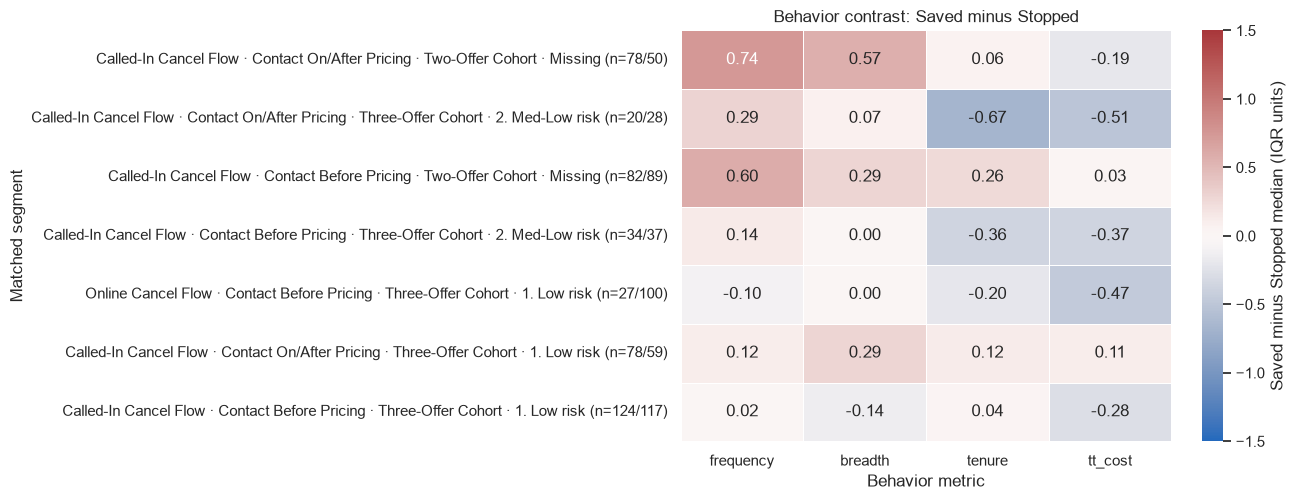

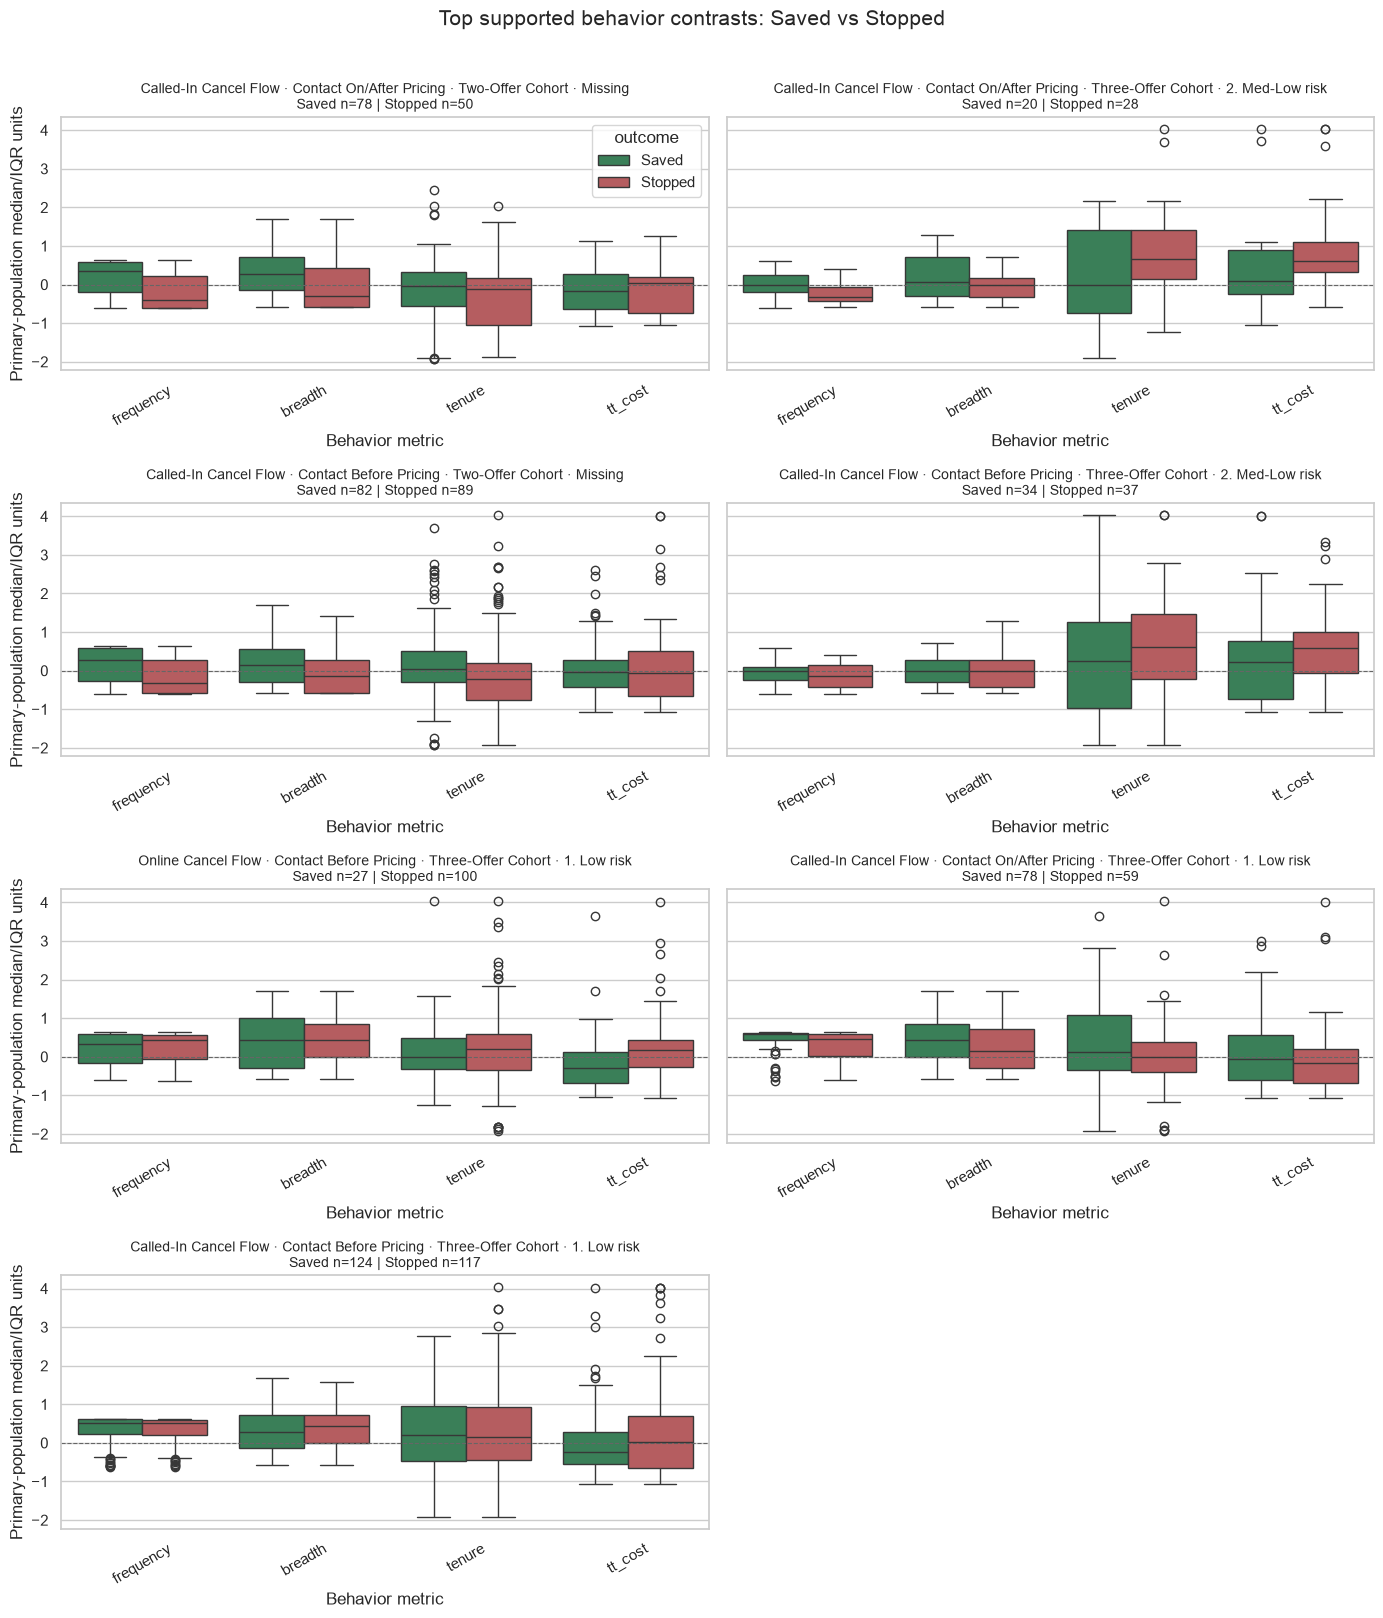

In [13]:
outcome_contrasts = build_outcome_contrasts(
    behavior_profiles,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
)
outcome_contrasts.to_csv(TABLE_DIR / "saved_minus_stopped_contrasts.csv", index=False)
display(outcome_contrasts.head(TOP_CONTRASTS))
_ = plot_profile_or_contrast_heatmap(
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    score_type="contrast",
    max_rows=20,
    color_limit=1.5,
    chart_folder=CONTRAST_CHART_DIR,
    title="Behavior contrast: Saved minus Stopped",
    file_name="saved_minus_stopped_contrasts.png",
    show=True,
)
_ = plot_top_behavior_contrasts(
    df_analysis,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    chart_folder=CONTRAST_CHART_DIR,
    file_name="top_behavior_contrasts.png",
    show=True,
)

## 7. Business magnitude and uncertainty for selected segments

Only the fixed top pooled-treatment segments are expanded. Raw clipped boxplots retain business units; the detail table reuses the selected contrast counts and adds clipped medians, IQRs, and optional bootstrap intervals for median differences. Full-value grids are intentionally omitted.

,segment_rank,segment_label,contact_channel_group,contact_timing,cohort,src_risk_tier,metric,n__saved,non_null__saved,clipped_median__saved,clipped_q25__saved,clipped_q75__saved,clipped_iqr__saved,n__stopped,non_null__stopped,clipped_median__stopped,clipped_q25__stopped,clipped_q75__stopped,clipped_iqr__stopped,clipped_median_difference,clipped_median_difference_ci_lower,clipped_median_difference_ci_upper,bootstrap_iterations,confidence_level
0,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,frequency,78,77,70.00,31.00,88.00,57.00,50,49,16.00,0.00,62.00,62.00,54.00,33.00,74.00,2000,0.95
1,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,breadth,78,77,6.00,3.00,9.00,6.00,50,49,2.00,0.00,7.00,7.00,4.00,1.00,6.00,2000,0.95
2,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,tenure,78,77,"1,425.00","1,118.00","1,636.00",518.00,50,49,"1,388.00",841.00,"1,556.00",715.00,37.00,-90.00,384.00,2000,0.95
3,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,tt_cost,78,77,408.26,256.21,551.45,295.24,50,49,472.53,221.06,530.47,309.41,-64.27,-117.39,122.21,2000,0.95
4,2,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,frequency,20,20,43.50,31.50,62.75,31.25,28,28,22.00,14.00,39.75,25.75,21.50,8.50,40.00,2000,0.95


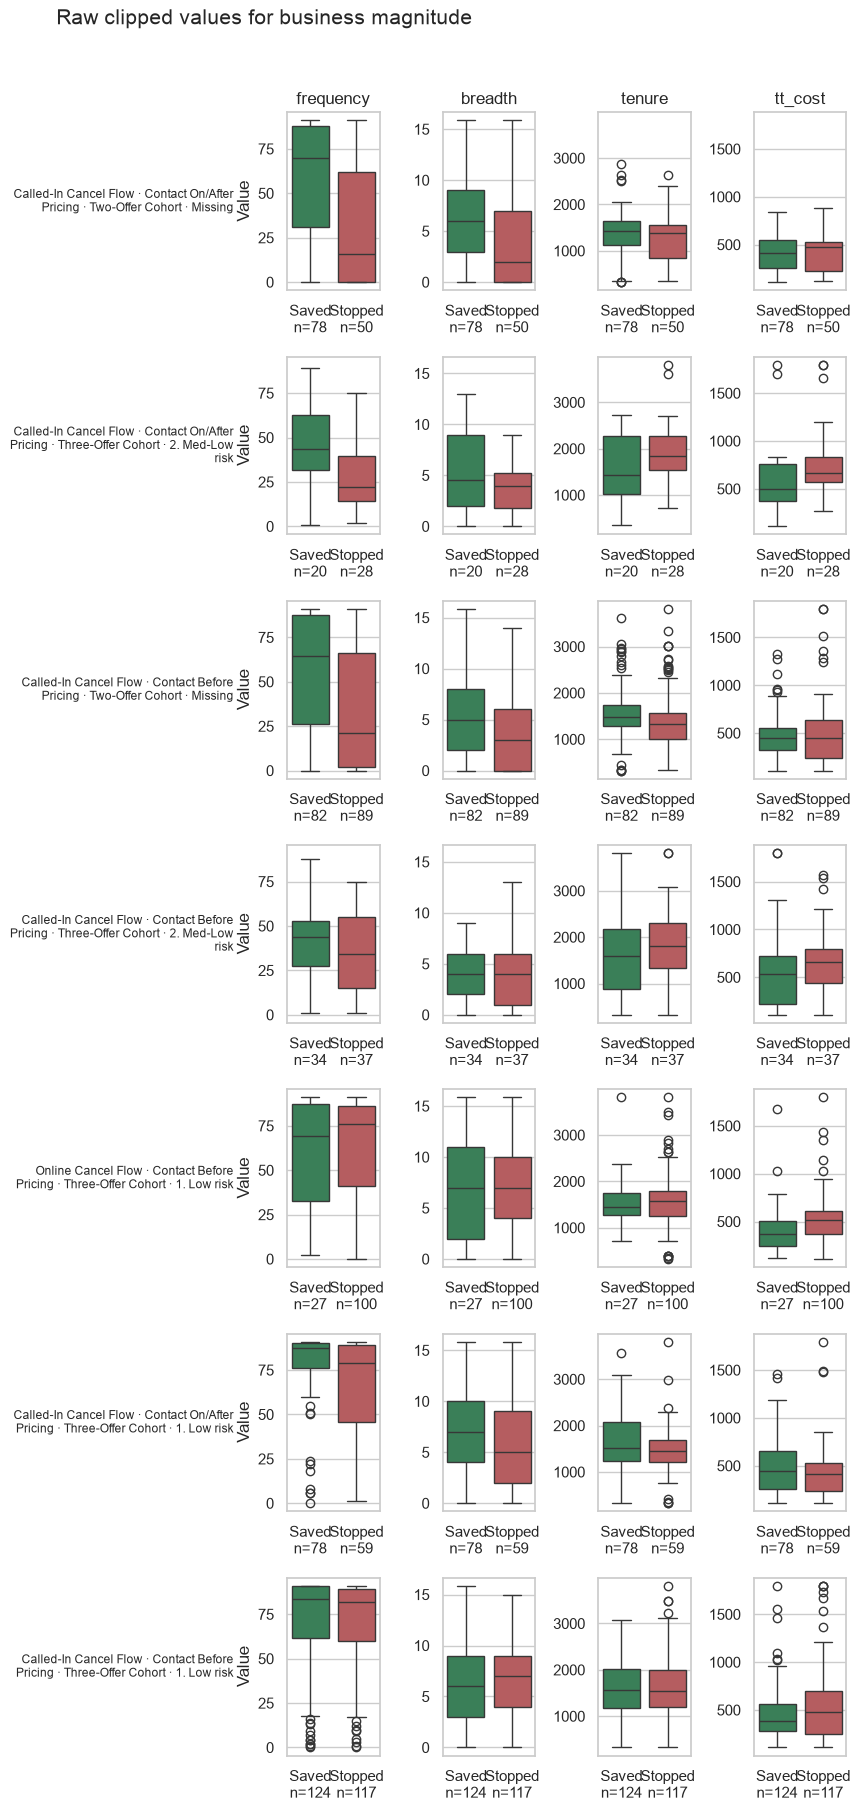

In [14]:
selected_segment_details = build_selected_segment_detail_table(
    df_analysis,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    bootstrap_iterations=BOOTSTRAP_ITERATIONS,
    confidence_level=BOOTSTRAP_CONFIDENCE_LEVEL,
)
selected_segment_details.to_csv(
    TABLE_DIR / "selected_segment_details.csv", index=False
)
display(selected_segment_details.head(5))
_ = plot_selected_segment_clipped_boxplot_grid(
    df_analysis,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    chart_folder=CONTRAST_CHART_DIR,
    file_name="selected_segments_raw_clipped.png",
    show=True,
)

## 8. Treatment drill-down within the selected segments

The segment list and ranks remain fixed from the pooled-treatment analysis above. This prevents small Treatment-specific cells from driving segment selection. A Treatment row is plotted only when both Saved and Stopped counts meet `MIN_TREATMENT_USERS`; unsupported rows remain in the exported table with counts and blank standardized differences. These are descriptive behavior contrasts, not treatment-effect or CNRC estimates.

,segment_rank,segment_label,contact_channel_group,contact_timing,cohort,src_risk_tier,Treatment,n__saved,n__stopped,total_users,observed_saved_share,supported,median_saved__frequency,median_saved__breadth,median_saved__tenure,median_saved__tt_cost,median_stopped__frequency,median_stopped__breadth,median_stopped__tenure,median_stopped__tt_cost,delta__frequency,delta__breadth,delta__tenure,delta__tt_cost,contrast_magnitude,dominant_metric
0,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Control,42,14,56,0.75,True,69.50,6.00,"1,434.50",420.25,6.00,1.50,"1,224.00",287.37,0.87,0.64,0.36,0.40,1.21,frequency
1,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Midpoint,36,36,72,0.50,True,78.00,5.00,"1,389.00",396.10,32.00,2.00,"1,419.00",474.53,0.63,0.43,-0.05,-0.24,0.80,frequency
2,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Tiered,0,0,0,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,2,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Control,8,4,12,0.67,False,40.50,2.00,"1,455.00",484.52,36.00,2.00,"1,635.50",902.18,NaN,NaN,NaN,NaN,NaN,None
4,2,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Midpoint,9,16,25,0.36,True,58.00,8.00,"1,174.00",474.19,19.00,3.50,"1,832.00",649.68,0.53,0.64,-1.13,-0.53,1.50,tenure


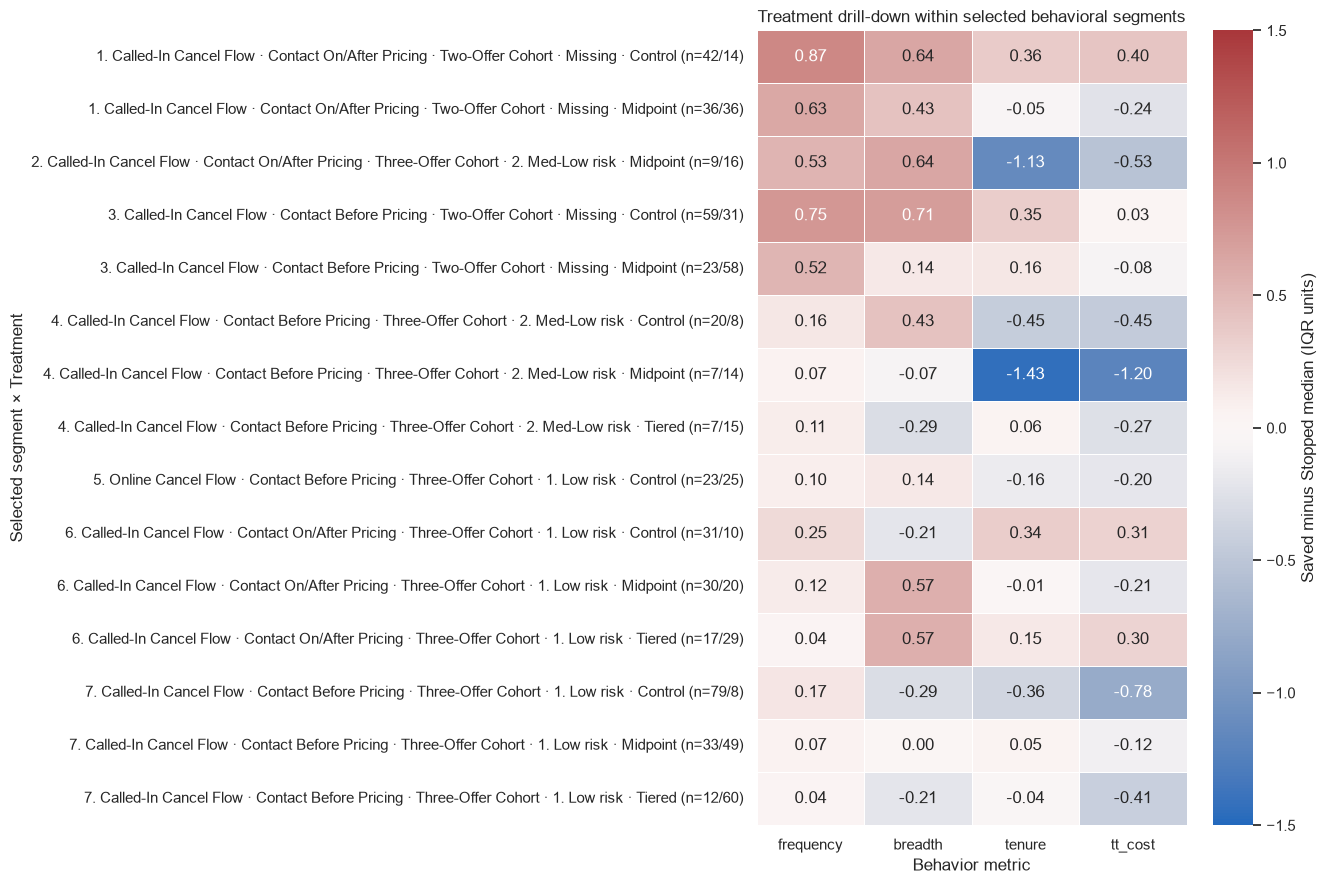

In [15]:
treatment_contrasts = build_treatment_contrasts(
    df_analysis,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    min_n=MIN_TREATMENT_USERS,
)
treatment_contrasts.to_csv(
    TABLE_DIR / "selected_segment_treatment_contrasts.csv", index=False
)
display(treatment_contrasts.head(5))
_ = plot_profile_or_contrast_heatmap(
    treatment_contrasts[treatment_contrasts["supported"]].copy(),
    metrics=NUMERIC_FIELDS,
    score_type="contrast",
    color_limit=1.5,
    title="Treatment drill-down within selected behavioral segments",
    chart_folder=CONTRAST_CHART_DIR,
    file_name="selected_segment_treatment_contrasts.png",
    show=True,
)

## 9. Interpretation guide

Use the repeated-call section to describe who tends to contact repeatedly, not to explain Saved-versus-Stopped differences. Use absolute profiles to characterize where a slice sits relative to all called-once contacts, and matched contrasts to state how Saved users differ from Stopped users inside the same slice. Confirm a ranked standardized contrast in the raw clipped chart before translating it into business magnitude.

Bootstrap intervals describe uncertainty in the observed median difference; they do not establish causality. Treatment-level patterns are hypotheses to reconcile with the completed randomized treatment/CNRC evaluation, especially when support is near the minimum.